In [27]:
import numpy as np
import pandas as pd
import clean_data_utils
import importlib
# importlib.reload(final_cleaned)
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
from sklearn import set_config             #using this code every transformation and all will comes in dataframe not in numpy
set_config(transform_output="pandas")

# Load the data

In [29]:
data = pd.read_csv('food_delivery_data.csv')
df = pd.DataFrame(data)
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

#clean data

In [30]:
clean_data_utils.perform_data_cleaning(df, saved_data_path='cleaned_data.csv')

In [31]:
df = pd.read_csv('cleaned_data.csv')
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,weather,traffic,vehicle_condition,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,sunny,high,2,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,stormy,jam,2,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,sandstorms,low,0,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,sunny,medium,0,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,cloudy,high,1,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,windy,high,1,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,windy,jam,0,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,cloudy,low,1,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,cloudy,high,0,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [32]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'weather', 'traffic', 'vehicle_condition', 'type_of_order',
       'type_of_vehicle', 'multiple_deliveries', 'festival', 'city_type',
       'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [33]:
## drop the columns which is not required for model input
columns_to_drop = [
    'rider_id',
    'restaurant_latitude',
    'restaurant_longitude',
    'delivery_latitude',
    'delivery_longitude',
    'order_day',
    'order_time_hour'
]
df.drop(columns=columns_to_drop,inplace=True)
df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,3,saturday,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,3,friday,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,3,saturday,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,4,tuesday,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,3,saturday,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,3,thursday,0,10.0,morning,1.489846,short
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,AGR,2,wednesday,0,15.0,evening,NaN,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,3,friday,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,3,monday,0,5.0,afternoon,6.232393,medium


In [34]:
df['pickup_time_minutes'].describe()

,pickup_time_minutes
count,43862.000000
mean,9.989399
std,4.087516
min,5.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,15.000000


In [35]:
df.shape

(45502, 19)

In [36]:
# check for missing values
df.isna().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


#data prepration

In [37]:
temp_df = df.copy().dropna()

In [38]:
temp_df['pickup_time_minutes'].describe()

,pickup_time_minutes
count,38064.000000
mean,9.979640
std,4.085783
min,5.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,15.000000


In [39]:
temp_df.shape

(38064, 19)

In [40]:
# split into  x and y
x = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

In [41]:
# train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(f'shape of train data {X_train.shape}')
print(f'shape of test data {X_test.shape}')

shape of train data (30451, 18)
shape of test data (7613, 18)


In [42]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [43]:
X_train.dtypes

,0
age,float64
ratings,float64
weather,object
traffic,object
vehicle_condition,int64
type_of_order,object
type_of_vehicle,object
multiple_deliveries,float64
festival,object
city_type,object


In [44]:
# df['time_taken'].value_counts()

In [45]:
#check for duplicate
df.duplicated().sum()

np.int64(0)

#preprocessing

In [46]:
num_col = ['age','ratings','pickup_time_minutes','distance']

nominal_cat_cols = ['type_of_order','type_of_vehicle','festival','city_type'
                   ,'city_name','weather'
                   ,'order_day_of_week','order_time_of_day']

ordinal_cat_cols = ['distance_type','traffic']


In [47]:

len(num_col + nominal_cat_cols + ordinal_cat_cols)

14

In [48]:
for col in ordinal_cat_cols:
  print(f'{col} has {temp_df[col].unique()}')


distance_type has ['short' 'very_long' 'medium' 'long']
traffic has ['high' 'jam' 'low' 'medium']


In [49]:
# genrate order for ordinal cols
distance_type_order = ['short', 'very_long' ,'medium' ,'long']
traffic_order   = [ 'low', 'medium','high','jam']

In [50]:
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("scale",MinMaxScaler(),num_col),
    ("nominal",OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),nominal_cat_cols),
    ("ordinal",OrdinalEncoder(categories=[distance_type_order,traffic_order]),ordinal_cat_cols)

],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

In [51]:
preprocessor.set_output(transform="pandas")

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'city_name',
                                  'weather', 'order_day_of_week',
                                  'order_time_of_day']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['short',
                                                             'very_long',
                                                             'medium', 'long'],
                                                            ['low', 'medium',
                                                             'high', 'jam']]),
                                 ['distance_type', 'traffic'])],
                  verbose_feature_names_out=False)

In [52]:
# transfor the data
X_train_transform = preprocessor.fit_transform(X_train)
X_test_transform  = preprocessor.transform(X_test)

In [53]:
#transform target column
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
y_train_transformed = pt.fit_transform(y_train.values.reshape(-1,1))   # by default
y_test_transformed  = pt.transform(y_test.values.reshape(-1,1))

# train the intial base model

In [54]:
from sklearn.linear_model import LinearRegression
ll = LinearRegression()

In [55]:
ll.fit(X_train_transform,y_train_transformed)

LinearRegression()

In [56]:
y_p = ll.predict(X_test_transform)

In [57]:
# get the prediction
y_pred_train = ll.predict(X_train_transform)
y_pred_test  = ll.predict(X_test_transform)

In [58]:
# get the actual prediction value

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org  = pt.inverse_transform(y_pred_test.reshape(-1,1))


In [60]:
# error calculation
from sklearn.metrics import mean_absolute_error,r2_score
y_train_mse  =  mean_absolute_error(y_train,y_pred_train_org)
y_test_mse   =  mean_absolute_error(y_test,y_pred_test_org)

print(f'training error of time_taken is {y_train_mse:.2f} minutes')
print(f'testing error of time_taken is {y_test_mse:.2f} minutes')


training error of time_taken is 4.69 minutes
testing error of time_taken is 4.75 minutes


In [61]:
print(f'r2_score of training data is {r2_score(y_train,y_pred_train_org)}')
print(f'r2_score on testing data is  {r2_score(y_test, y_pred_test_org)}')

r2_score of training data is 0.6007106020274816
r2_score on testing data is  0.5959919928215329


 this is error when i drop the missing value of data set directly

# impute missing value

In [62]:
X = df.drop(columns=['time_taken'])
y = df['time_taken']

In [63]:
X.isna().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt  = pt.transform(y_test.values.reshape(-1,1))

In [ ]:
X_train.isna().sum()

In [ ]:
# percentage of rows  in  data have missing values
X_train.isna().any(axis=1).mean().round(2)*100

#age column

In [ ]:
X_train['age'].describe()

In [ ]:
age_median = X_train['age'].median()

In [ ]:
import seaborn as sns
sns.kdeplot(X_train['age'],label='original')
sns.kdeplot(X_train['age'].fillna(age_median),label='filled nan value')
plt.legend()

1. filling the null  value using the median change the distribution of the data here before

use another advance imputer technique

# imputation on ratings

In [64]:
X_train['ratings'].describe()

,ratings
count,30451.000000
mean,4.632426
std,0.315168
min,2.500000
25%,4.500000
50%,4.700000
75%,4.900000
max,5.000000


In [65]:
# average is not very much far from the min and max we can try with average value
avg_rating = X_train['ratings'].mean()

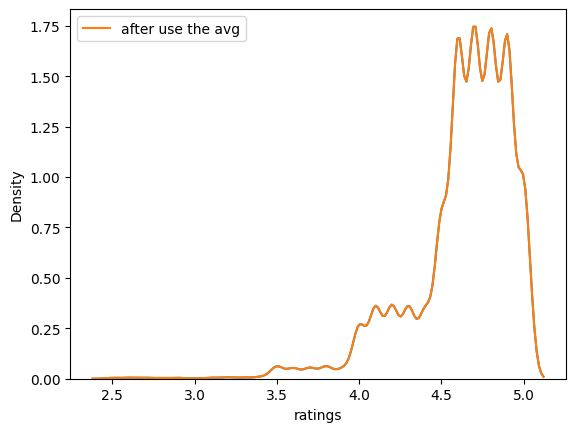

In [66]:
sns.kdeplot(X_train['ratings'])
sns.kdeplot(X_train['ratings'].fillna(avg_rating),label='after use the avg')
plt.legend()

1.not much difference as compare to the age we can go with mean
we can also use advanced imputer technique

# weather column imputer

In [67]:
X_train['weather'].value_counts()

,count
weather,
fog,5193
stormy,5136
sandstorms,5117
cloudy,5086
windy,5037
sunny,4882


<Axes: xlabel='count', ylabel='weather'>

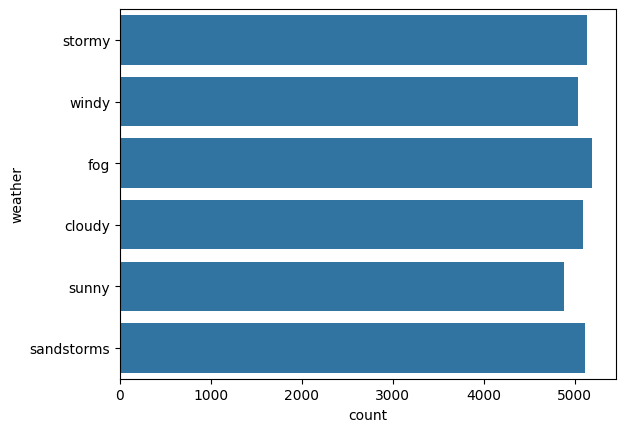

In [68]:
sns.countplot(X_train['weather'])

no dominating category from which we can impute the nan value

In [69]:
# capture the missingness
from sklearn.impute import MissingIndicator
missing_weather = MissingIndicator()
missing_weather.set_output(transform="pandas")

pd.concat([X_train['weather'],missing_weather.fit_transform(X_train[['weather']]) ],axis=1).sample(50)


,weather
32046,sunny
11762,stormy
10112,sandstorms
42357,windy
9233,cloudy
42903,windy
41143,sandstorms
19766,windy
26540,stormy
8113,sandstorms


# impute the traffic column

In [70]:
X_train['traffic'].value_counts()

,count
traffic,
low,10248
jam,9724
medium,7495
high,2984


<Axes: xlabel='count', ylabel='traffic'>

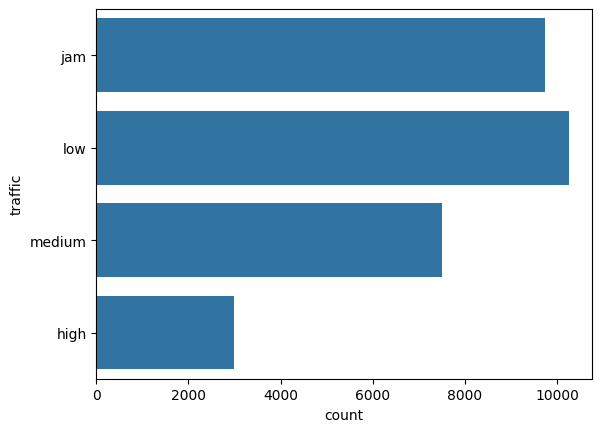

In [71]:
sns.countplot(X_train['traffic'])

no dominating category here we can use missing indicator

In [72]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


#multiple_deliveries  imputation

In [75]:
multiple_delivery_mode = X_train['multiple_deliveries'].mode()

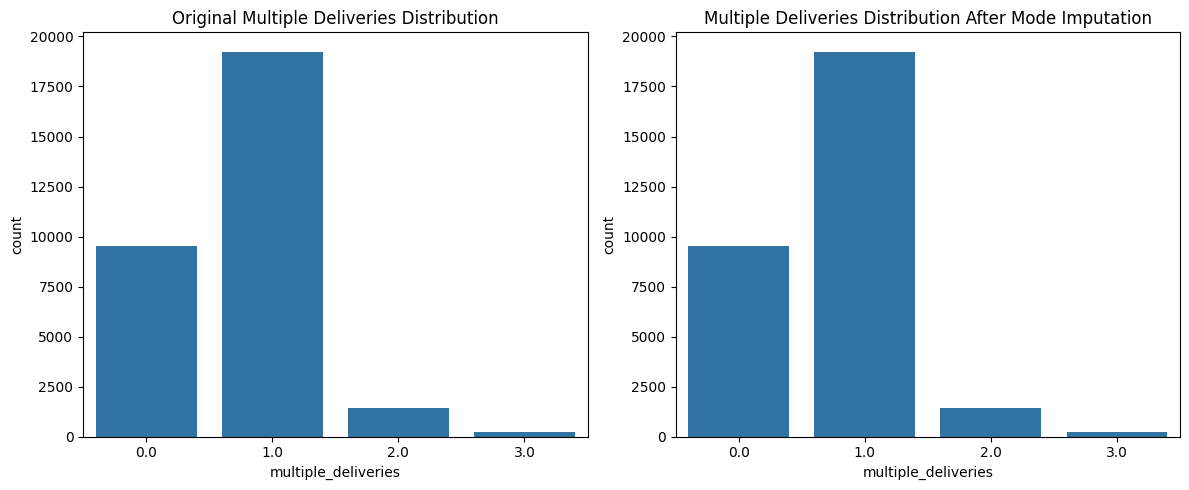

In [76]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=X_train['multiple_deliveries'].apply(str))
plt.title('Original Multiple Deliveries Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x=X_train['multiple_deliveries'].fillna(multiple_delivery_mode).apply(str))
plt.title('Multiple Deliveries Distribution After Mode Imputation')

plt.tight_layout()
plt.show()

In [77]:
X_train['multiple_deliveries'].value_counts()

,count
multiple_deliveries,
1.0,19245
0.0,9544
2.0,1411
3.0,251


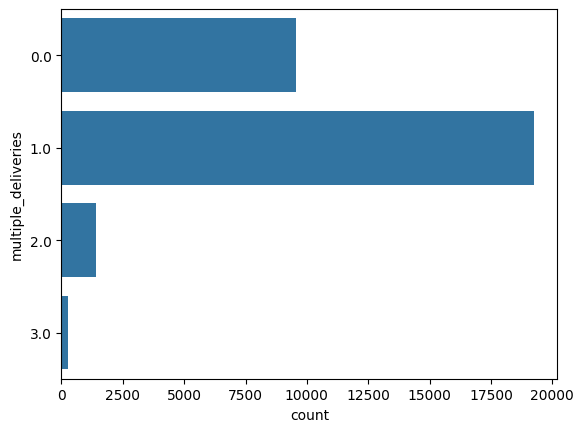

In [78]:
sns.countplot(X_train['multiple_deliveries'].apply(str))
plt.show()

In [79]:
# multiple delivery one is dominating
multiple_delivery_mode = X_train['multiple_deliveries'].mode()[0]

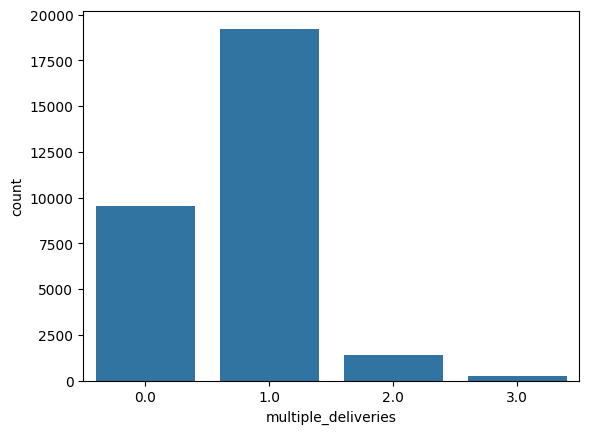

In [80]:
sns.countplot(x=X_train['multiple_deliveries'].fillna(multiple_delivery_mode).apply(str))
plt.show()

 after imputation not much distribution is change so we can use this technique

#festival imputation

In [81]:
X_train['festival'].value_counts()

,count
festival,
no,29846
yes,605


In [82]:
X_train['city_type'].value_counts()

,count
city_type,
metropolitian,23434
urban,6909
semi-urban,108


<Axes: xlabel='count', ylabel='festival'>

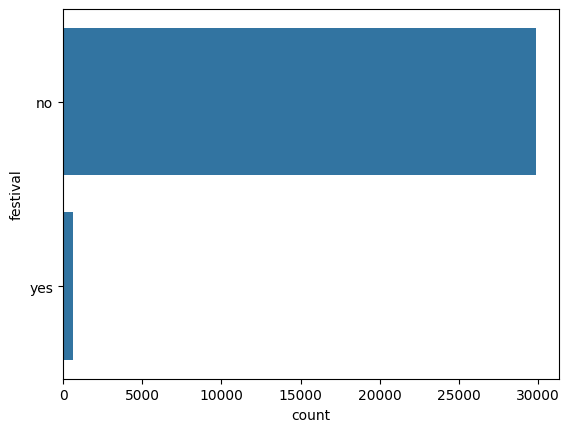

In [83]:
sns.countplot(X_train['festival'])

no is dominating here

In [84]:
# model value of festival
festival_mode = X_train['festival'].mode()[0]

<Axes: xlabel='count', ylabel='festival'>

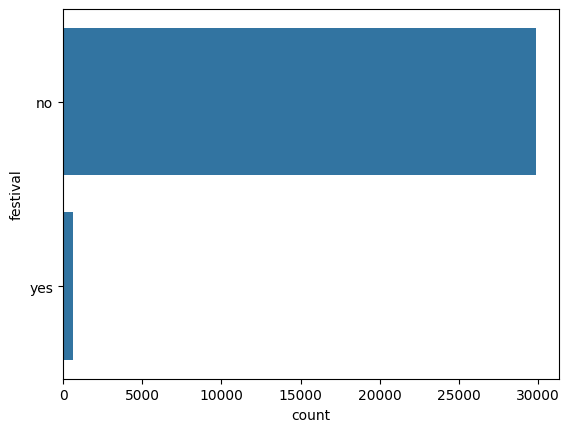

In [85]:
sns.countplot(X_train['festival'].fillna(festival_mode))

# city type imputation

In [86]:
X_train['city_type'].value_counts()

# here metroplitian is dominating

mode_city_type = X_train['city_type'].mode()[0]

<Axes: xlabel='count', ylabel='city_type'>

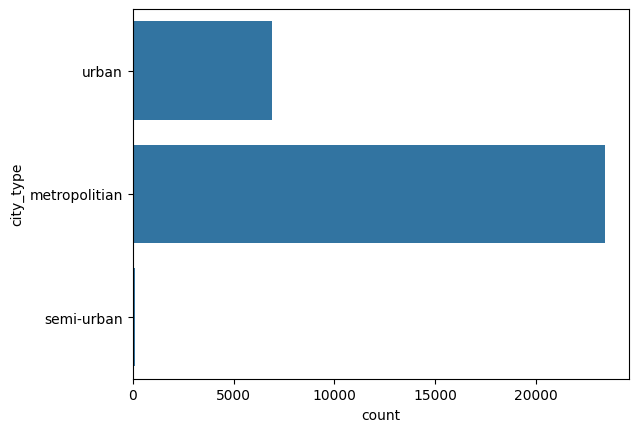

In [87]:
sns.countplot(X_train['city_type'])

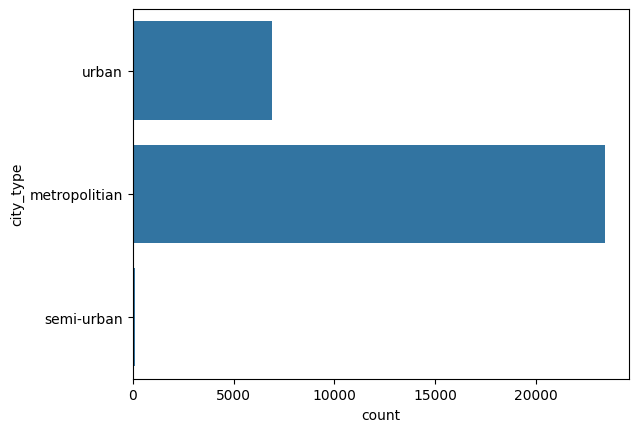

In [88]:
sns.countplot(X_train['city_type'].fillna(mode_city_type))
plt.show()

# pickup time imputation

In [89]:
X_train['pickup_time_minutes'].describe()

,pickup_time_minutes
count,30451.000000
mean,9.953532
std,4.083123
min,5.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,15.000000


In [90]:
# missing value in the column
X_train['pickup_time_minutes'].isnull().sum()

np.int64(0)

In [91]:
# median value
median_value_pickup_time = X_train['pickup_time_minutes'].median()

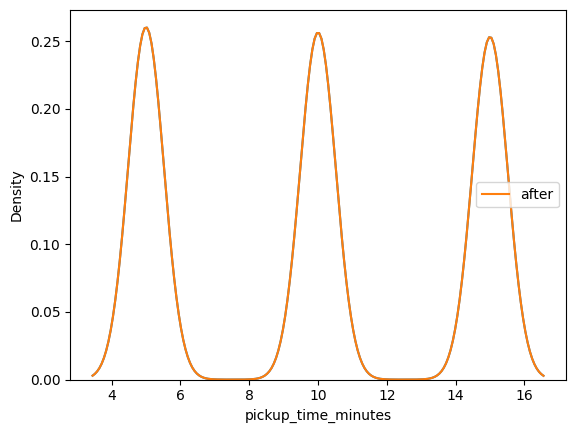

In [92]:
sns.kdeplot(X_train['pickup_time_minutes'])
sns.kdeplot(X_train['pickup_time_minutes'].fillna(median_value_pickup_time),label='after')
plt.legend()

In [93]:
df.isnull().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


# order_time_of_day ------------> imputation

In [94]:

X_train['order_time_of_day'].value_counts()

,count
order_time_of_day,
evening,9560
night,9522
morning,5884
afternoon,5178
after_midnight,307


<Axes: xlabel='count', ylabel='order_time_of_day'>

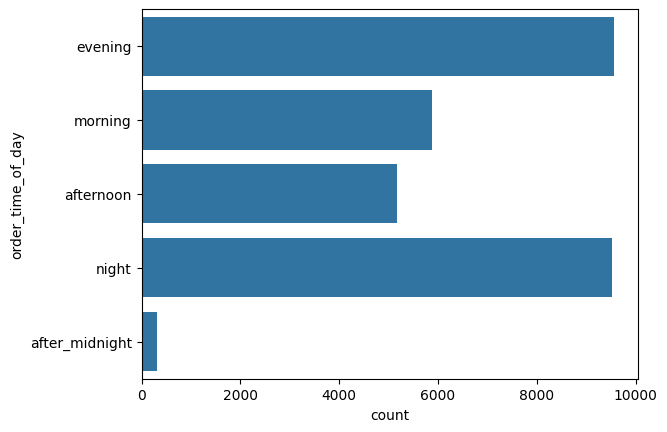

In [95]:
sns.countplot(X_train['order_time_of_day'])

still there is not one dominating category

#distance  imputation

In [96]:
X_train['distance'].describe()

,distance
count,30451.000000
mean,9.773889
std,5.599056
min,1.465067
25%,4.658256
50%,9.220148
75%,13.681486
max,20.969489


In [97]:
mean_distance = X_train['distance'].mean()

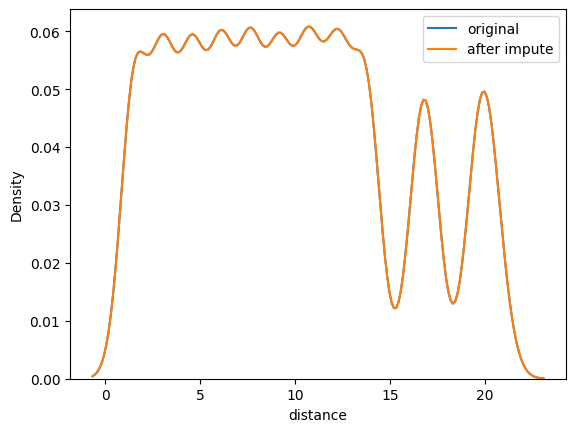

In [98]:
sns.kdeplot(X_train['distance'],label='original')
sns.kdeplot(X_train['distance'].fillna(mean_distance),label='after impute')
plt.legend()

#distance_type

In [99]:
X_train['distance_type'].value_counts()

,count
distance_type,
long,8260
medium,8199
short,8073
very_long,5919


<Axes: xlabel='count', ylabel='distance_type'>

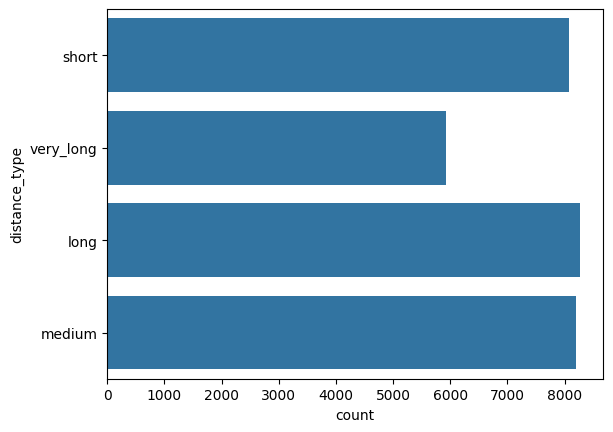

In [100]:
sns.countplot(X_train['distance_type'])

here is also no one is dominating

#Imputation pipline

In [101]:
nominal_cat_cols

['type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'city_name',
 'weather',
 'order_day_of_week',
 'order_time_of_day']

In [ ]:
X_train.isnull().sum()

In [102]:
# feature to fill value with mode
features_to_fill_mode = ['multiple_deliveries','festival','city_name']
features_to_fill_missing = [ col for col in nominal_cat_cols if col not in features_to_fill_mode ]
features_to_fill_missing

['type_of_order',
 'type_of_vehicle',
 'city_type',
 'weather',
 'order_day_of_week',
 'order_time_of_day']

In [ ]:
# ordinal_cat_cols  -> this is also comes under feature to fill missing because it will also not comes under the dominating

In [103]:
# simpleimputer to fill mode value
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

simple_imputer = ColumnTransformer(transformers= [
     ("mode_imputer",SimpleImputer(strategy="most_frequent"),features_to_fill_mode),
     ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing"),features_to_fill_missing) # i did this because the one-hot encode ignore the null value so we use this to make a new category for missing value
     ],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['multiple_deliveries', 'festival',
                                  'city_name']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['type_of_order', 'type_of_vehicle',
                                  'city_type', 'weather', 'order_day_of_week',
                                  'order_time_of_day'])],
                  verbose_feature_names_out=False)

In [ ]:
# fit -transform on our dataset
simple_imputer.fit_transform(X_train)

In [104]:
# X_train_transform.isna().sum()

In [105]:
## knn-imputer using
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors = 5)

In [106]:
# bulid preprocessor again
from sklearn.compose import ColumnTransformer
from  sklearn.preprocessing import MinMaxScaler,OneHotEncoder,OrdinalEncoder
preprocessor = ColumnTransformer([
              ("scale",MinMaxScaler(),num_col),
              ("nominal_encode",OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False),nominal_cat_cols),
              ("ordinal_encode",OrdinalEncoder(categories=[distance_type_order,traffic_order],
                                               encoded_missing_value=-999,
                                               handle_unknown="use_encoded_value",
                                               unknown_value=-1),ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)


In [ ]:
preprocessor.fit_transform(X_train).isnull().sum().loc[lambda ser : ser.ge(1)]

In [107]:
##---------- pipline for all this
from sklearn.pipeline import Pipeline

preprocessing_pipline = Pipeline(steps=[
    ("simple_imputer",simple_imputer),
    ("preprocess",preprocessor),
    ("knn_imputer",knn_imputer)
])

In [ ]:
preprocessing_pipline

In [108]:
preprocessing_pipline.fit_transform(X_train)

,age,ratings,pickup_time_minutes,distance,type_of_order_drinks,type_of_order_meal,type_of_order_snack,type_of_vehicle_motorcycle,type_of_vehicle_scooter,festival_yes,...,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,distance_type,traffic,multiple_deliveries,vehicle_condition,order_month,is_weekend
24939,0.052632,0.80,0.5,0.163629,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,3.0,0.0,1.0,3.0,0.0
9439,0.526316,0.96,1.0,0.157036,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,3.0,1.0,2.0,3.0,0.0
18409,0.631579,1.00,0.0,0.160160,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,3.0,2.0,2.0,3.0,1.0
15267,0.789474,0.96,0.5,0.003145,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0
43924,0.157895,0.88,0.5,0.084651,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20042,0.368421,0.88,1.0,0.621266,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,3.0,1.0,1.0,2.0,4.0,1.0
7521,0.842105,0.88,0.0,0.788907,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,3.0,1.0,0.0,3.0,1.0
13483,0.736842,0.92,0.5,0.154044,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,3.0,0.0
1038,0.368421,0.92,0.5,0.992901,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,2.0,0.0


In [109]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

model_pipe = Pipeline(steps=[
    ("preprocessing",preprocessing_pipline),
    ("model",lr)
     ])

In [110]:
model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_name']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['type_...
                                                                    'order_day_of_week',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['short',
                                                                                               'very_long',
                                                                                               'medium',
                                                                                               'long'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['distance_type',
                                                                    'traffic'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [111]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))

In [112]:
# fit the pipeline on the data
model_pipe.fit(X_train,y_train_pt)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_name']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['type_...
                                                                    'order_day_of_week',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['short',
                                                                                               'very_long',
                                                                                               'medium',
                                                                                               'long'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['distance_type',
                                                                    'traffic'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [113]:
y_pred_train = model_pipe.predict(X_train)

In [114]:
y_pred_test  = model_pipe.predict(X_test)

In [115]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
pt.fit(y_train.values.reshape(-1,1))
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org  = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [116]:
from sklearn.metrics import mean_absolute_error, r2_score
print(f'error on train data {mean_absolute_error(y_train,y_pred_train_org)}')
print(f'error on test data {mean_absolute_error(y_test,y_pred_test_org)}')
print(f'r2_score on training is {mean_absolute_error(y_train,y_pred_train_org)}')
print(f'r2_score on testing  is {mean_absolute_error(y_test,y_pred_test_org)}')

error on train data 4.690050919423251
error on test data 4.754001868584869
r2_score on training is 4.690050919423251
r2_score on testing  is 4.754001868584869


In [117]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import  Pipeline
rf = RandomForestRegressor(random_state=42,n_jobs=-1)

model_pipe = Pipeline(steps=[
    ("preprocessing",preprocessing_pipline),
    ("model",rf)
])


In [ ]:
model_pipe

In [118]:
model_pipe.fit(X_train,y_train_pt)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_name']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['type_...
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['short',
                                                                                               'very_long',
                                                                                               'medium',
                                                                                               'long'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['distance_type',
                                                                    'traffic'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [119]:
y_pred_train = model_pipe.predict(X_train)
y_pred_test  = model_pipe.predict(X_test)

In [120]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
pt.fit(y_train.values.reshape(-1,1))
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org  = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [121]:
print(f'error on the train data {mean_absolute_error(y_train,y_pred_train_org)}')
print(f'error on the test  data {mean_absolute_error(y_test,y_pred_test_org)}')

error on the train data 1.1468368928534356
error on the test  data 3.130593768832941


In [122]:
print(f'r2 on train {r2_score(y_train,y_pred_train_org)}')
print(f'r2 on test {r2_score(y_test,y_pred_test_org)}')

r2 on train 0.9757491667257995
r2 on test 0.8249612987391888


In [123]:
import joblib

joblib.dump(model_pipe, "model.pkl")

print("model.pkl created successfully")

model.pkl created successfully
